In [1]:
import random
import IPython
import functools
# import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
# Import torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn


# Check that we are using a GPU, if not switch runtimes
#   using Runtime > Change Runtime Type > GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    cudnn.benchmark = True
else:
  raise ValueError("GPU is not available. Change Colab runtime.")

### Positive Samples - FairFace Dataset

In [ ]:
import torch
from datasets import load_dataset
from torchvision import transforms, datasets
from torch.utils.data import Dataset

# Define Transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# using '0.25' for a smaller dataset
fairface_dataset = load_dataset('HuggingFaceM4/FairFace', '0.25', split='train')

# Define the Transform Function 
def apply_fairface_transform(batch):
    # Images are coming as batches
    # Apply transform to image in the batch list
    transformed_images = [transform(img) for img in batch['image']]
    
    # Create a list of labels (1) 
    labels = [1] * len(transformed_images)
    
    # Return a dictionary of lists
    return {'image': transformed_images, 'label': labels}

# Apply the transform
fairface_data = fairface_dataset.with_transform(apply_fairface_transform)

# 5. The Wrapper Class
class FairFaceWrapper(Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset
    
    def __len__(self):
        return len(self.hf_dataset)
    
    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        return item['image'], item['label']


positive_samples = FairFaceWrapper(fairface_data)

# Access the first item
first_image, first_label = positive_samples[0]

print(f"Image Shape: {first_image.shape}")
print(f"Label: {first_label}")            

Success!
Image Shape: torch.Size([3, 64, 64])
Label: 1


In [111]:
first_image

tensor([[[0.4627, 0.4549, 0.4392,  ..., 0.4471, 0.4431, 0.4431],
         [0.4314, 0.4235, 0.4157,  ..., 0.4471, 0.4471, 0.4471],
         [0.3647, 0.3647, 0.3647,  ..., 0.4471, 0.4510, 0.4510],
         ...,
         [0.6039, 0.6039, 0.6039,  ..., 0.5608, 0.5569, 0.5529],
         [0.6000, 0.6000, 0.6000,  ..., 0.5725, 0.5686, 0.5647],
         [0.6000, 0.6000, 0.5961,  ..., 0.5804, 0.5765, 0.5725]],

        [[0.6157, 0.6196, 0.6314,  ..., 0.6314, 0.6314, 0.6314],
         [0.5804, 0.5882, 0.6039,  ..., 0.6353, 0.6353, 0.6353],
         [0.5059, 0.5216, 0.5451,  ..., 0.6392, 0.6392, 0.6392],
         ...,
         [0.6078, 0.6118, 0.6157,  ..., 0.5725, 0.5686, 0.5647],
         [0.6078, 0.6078, 0.6118,  ..., 0.5843, 0.5804, 0.5765],
         [0.6078, 0.6078, 0.6078,  ..., 0.5882, 0.5843, 0.5843]],

        [[0.7333, 0.7412, 0.7608,  ..., 0.8118, 0.8118, 0.8118],
         [0.6941, 0.7059, 0.7294,  ..., 0.8196, 0.8196, 0.8157],
         [0.6157, 0.6314, 0.6706,  ..., 0.8353, 0.8314, 0.

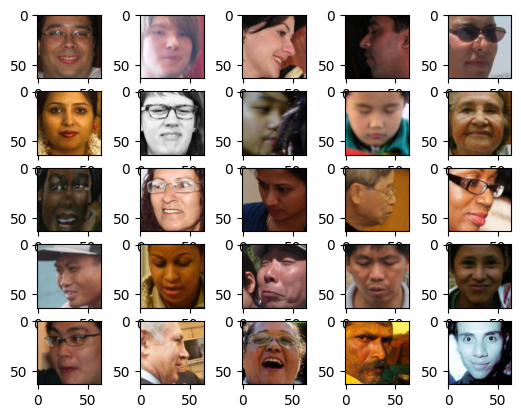

In [ ]:
import matplotlib.pyplot as plt
for i in range(25):
    plt.subplot(5, 5, i + 1)
    first_image, first_label = positive_samples[70000-i]
    image_np = first_image.permute(1,2,0).numpy()
    plt.imshow(image_np)

### Negative Samples - CIFAR10

In [57]:
class CIFAR10NegativeWrapper(datasets.CIFAR10):
    def __getitem__(self, index):
        # img is the transformed tensor, _ is the original CIFAR label
        img, _ = super().__getitem__(index) 
        # Return the image and the NEGATIVE label (0)
        return img, 0

negative_samples = CIFAR10NegativeWrapper(
    root='./data',
    train=True,
    download=True, 
    transform=transform
)

100%|██████████| 170M/170M [00:07<00:00, 22.6MB/s] 


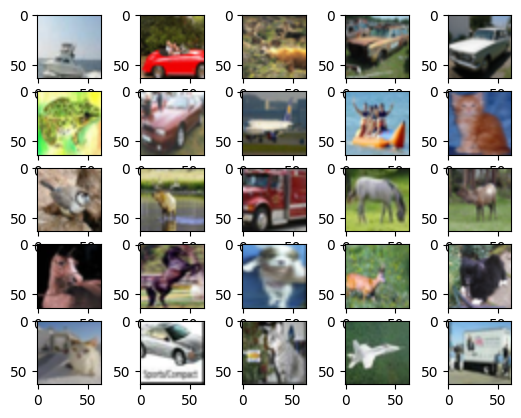

In [60]:
for i in range(25):
    plt.subplot(5, 5, i + 1)
    first_image, first_label = negative_samples[100-i]
    image_np = first_image.permute(1,2,0).numpy()
    plt.imshow(image_np)

In [ ]:
# # MIT introduction to deep learning package
# # %pip install mitdeeplearning --quiet
# import mitdeeplearning as mdl

In [ ]:
# CACHE_DIR = Path.home() / ".cache" / "face"
# CACHE_DIR.mkdir(parents=True, exist_ok=True)

# # Get the training data: both images from CelebA and ImageNet
# path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# # Create a simple check to avoid re-downloading
# if path_to_training_data.is_file():
#     print(f"Using cached training data from {path_to_training_data}")
# else:
#     print(f"Downloading training data to {path_to_training_data}")
#     url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
#     torch.hub.download_url_to_file(url, path_to_training_data)


100%|██████████| 1.18G/1.18G [01:12<00:00, 17.4MB/s]


In [ ]:
# import h5py
# import torch
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# import torch
# from torch.utils.data import Subset
# from torch.utils.data import DataLoader

# class H5FaceDataset(Dataset):
#     def __init__(self, h5_path, transform=None, channels_last=False):
#         self.file = h5py.File(h5_path, "r")
#         self.images = self.file["images"]
#         self.labels = self.file["labels"] if "labels" in self.file else None
#         self.transform = transform
#         self.channels_last = channels_last

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img = self.images[idx]
#         if not self.channels_last:
#             # convert from HWC → CHW
#             img = img.transpose(2, 0, 1)

#         img = torch.tensor(img, dtype=torch.float32) / 255.0  # normalize to [0,1]
        
#         if self.labels is not None:
#             label = torch.tensor(self.labels[idx], dtype=torch.long)
#             return img, label
#         else:
#             return img

# # Now, create a single transform that includes Resize
# # Note: apply Resize *after* the tensor is created and normalized [0,1]
# # add antialias=True to match modern PyTorch defaults.
# transform = transforms.Compose([
#     transforms.Resize((64,64), antialias=True), 
# ])

# # Create a simple wrapper dataset to apply the transform *after* subsetting
# class TransformedSubset(Dataset):
#     def __init__(self, subset, transform):
#         self.subset = subset
#         self.transform = transform
#     def __getitem__(self, index):
#         x, y = self.subset[index]
#         return self.transform(x), y
#     def __len__(self):
#         return len(self.subset)

# dataset = H5FaceDataset(path_to_training_data)


In [ ]:
# import numpy as np
# labels = np.array(dataset.labels)
# import torch
# from collections import Counter
# label_counts = Counter(labels.squeeze())
# print(label_counts)

Counter({np.uint8(0): 54957, np.uint8(1): 54957})


### Create a training dataset

In [75]:
from torch.utils.data import Subset, ConcatDataset, DataLoader, random_split

N_SAMPLES = 5000

# Indices for the first 5000 images (0 to 4999)
indices = list(range(N_SAMPLES))

# Create the Subsets
# This physically restricts the datasets to only those 5000 images each
pos_subset_5k = Subset(positive_samples, indices)
neg_subset_5k = Subset(negative_samples, indices)

# --- 2. Combine them into one balanced dataset ---
# Total size will be 10,000 (5000 faces + 5000 non-faces)
combined_dataset = ConcatDataset([pos_subset_5k, neg_subset_5k])

print(f"Combined Dataset Size: {len(combined_dataset)}")

train_size = int(0.8 * len(combined_dataset))
valid_size = len(combined_dataset) - train_size

# random_split handles the shuffling and splitting for you
train_dataset, valid_dataset = random_split(
    combined_dataset, 
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

# Shuffle ONLY the training loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Valid samples: {len(valid_dataset)}")

Combined Dataset Size: 10000
Train samples: 8000
Valid samples: 2000


### Create Test dataset

In [78]:
TEST_START_INDEX = 5000
TEST_SIZE = 500
TEST_INDICES = list(range(TEST_START_INDEX, TEST_START_INDEX + TEST_SIZE))


pos_test_subset = Subset(positive_samples, TEST_INDICES)
neg_test_subset = Subset(negative_samples, TEST_INDICES)

test_dataset = ConcatDataset([pos_test_subset, neg_test_subset])

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False 
)

print(f"Test Dataset Size: {len(test_dataset)}")

Test Dataset Size: 1000


In [ ]:
# # Get indices for each class
# labels = torch.from_numpy(np.array(dataset.labels))  # all labels
# class0_indices = torch.where(labels == 0)[0][:2000]  # non-faces
# class1_indices = torch.where(labels == 1)[0][:2000]  # faces

# # Combine indices
# selected_indices = torch.cat([class0_indices, class1_indices])
# # shuffle
# selected_indices = selected_indices[torch.randperm(len(selected_indices))]


# # Split into train/validation (80/20)
# # Create a subset dataset
# small_dataset = Subset(dataset, selected_indices)

# train_size = int(0.8 * len(small_dataset))
# valid_size = len(small_dataset) - train_size

# train_dataset, valid_dataset = torch.utils.data.random_split(
#     small_dataset, [train_size, valid_size],
#     generator=torch.Generator().manual_seed(42)
# )

# # Apply the wrapper to your train/valid subsets
# train_dataset_transformed = TransformedSubset(train_dataset, transform)
# valid_dataset_transformed = TransformedSubset(valid_dataset, transform)

# # Create DataLoaders

# batch_size = 32
# train_loader = DataLoader(train_dataset_transformed, batch_size=batch_size, shuffle=True)
# valid_loader = DataLoader(valid_dataset_transformed, batch_size=batch_size, shuffle=False)

In [ ]:
# len(train_loader), len(valid_loader)

(100, 25)

In [ ]:
# Get first batch
images, labels = next(iter(train_loader))

# Check shapes
print("Images shape:", images.shape)  # [batch_size, channels, height, width]
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


In [ ]:
# # Dislay images
# ### Examining the CelebA training dataset ###
# import matplotlib.pyplot as plt

# face_images = images[np.where(labels == 1)[0]].permute(0, 2, 3, 1)
# not_face_images = images[np.where(labels== 0)[0]].permute(0, 2, 3, 1)
# idx_face = 10
# idx_not_face = 7
# plt.figure(figsize=(5, 5))
# plt.subplot(1, 2, 1)

# if len(face_images) > 0:
#     plt.imshow(face_images[idx_face])
#     plt.title("Face")
# else:
#     plt.title("No Face images in batch")

# plt.grid(False)

# plt.subplot(1, 2, 2)
# if len(not_face_images) > 0:
#     plt.imshow(not_face_images[idx_not_face])
#     plt.title("Not Face")
# else:
#     plt.title("No Not Face images in batch")
# plt.grid(False)

In [9]:
class Face_CNN(nn.Module):
  def __init__(self, output=1):
    super(Face_CNN, self).__init__()
    # Build the layers
    # Block 1 
    self.output=output
    
    #o/p = [w + 2p -k]/s + 1
    self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3,stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
    
    self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 *4 *4, 256),
            nn.ReLU(),
            nn.Linear(256, output)
        )
  def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

check_model = Face_CNN()
print(check_model)

Face_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(

In [82]:
images, labels = next(iter(train_loader))
dummy = images[0].to(device).unsqueeze(0)
dummy.shape


torch.Size([1, 3, 64, 64])

In [83]:
check_model.to(device)
output = check_model(dummy)
print(check_model)

Face_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(

# Train and test the CNN model

In [6]:
from prompt_toolkit import history
from torchvision.io.video import av

class Trainer:
  def __init__(self, model, optimizer, loss_function, device=None):
    self.loss_function = loss_function
    self.optimizer = optimizer
    self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model
    self.model.to(self.device)
    print(f"Trainer Object Initialized on Device: {self.device}")

  def _train_epoch(self, train_loader, verbose=False):
    """Internal Training method for a epoch

      return traing loss, training accuracy for one epoch
    """
    self.model.train() # Set the model in training mode

    correct, total = 0, 0
    training_loss = []

    loop = tqdm(train_loader, desc="Training", leave = False) if verbose else train_loader
    # Training loop
    for x_batch, y_batch in loop:
      x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)

      # Forward pass
      outputs = self.model(x_batch)
      self.model.zero_grad()

      # Calculate loss and accuracy
      loss = self.loss_function(outputs.squeeze(), y_batch.float().squeeze()) # Cast y_batch to float and squeeze
      loss.backward()
      self.optimizer.step()
      training_loss.append(loss.item())

      total += len(x_batch)
      predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze() # Correct prediction for BCEWithLogitsLoss
      correct += (predicted == y_batch.squeeze()).sum().item()

      if verbose:
        loop.set_postfix(loss=loss.item(), accuracy=100* correct/total)

    avg_train_loss = np.mean(training_loss)
    train_accuracy = correct / total * 100
    return avg_train_loss, train_accuracy

  def _validate_epoch(self, valid_loader, verbose=False,  return_probs=False):
      """ Internal Validation method for a epoch

      return validation loss, validation accuracy for one epoch
      """

      self.model.eval() # Set the model in evaluation mode
      all_probs = []  # To store probabilities if needed
      correct, total = 0, 0
      validation_loss = []
      loop = tqdm(valid_loader, desc="Validation", leave = False) if verbose else valid_loader

      for x_val, y_val in loop:
        x_val, y_val = x_val.to(self.device), y_val.to(self.device)
        with torch.no_grad():
          outputs = self.model(x_val)
          loss = self.loss_function(outputs.squeeze(), y_val.float().squeeze()) # Cast y_val to float and squeeze
          validation_loss.append(loss.item())
          # Store probabilities if needed
          probs = torch.sigmoid(outputs).squeeze()
          if return_probs:
                all_probs.append(probs.cpu())

          total += len(x_val)
          predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze() # Correct prediction for BCEWithLogitsLoss
          correct += (predicted == y_val.squeeze()).sum().item()
          if verbose:
            loop.set_postfix(loss=loss.item(), accuracy=100* correct/total)

      avg_val_loss = np.mean(validation_loss)
      val_accuracy = correct / total * 100
      
      if return_probs:
        return avg_val_loss, val_accuracy, torch.cat(all_probs, dim=0)
    
      return avg_val_loss, val_accuracy

  def fit(self, train_loader, validation_loader, epochs=10, verbose=True):
      """Trains and evaluates the model for a specified number of epochs."""
      history = {
              "train_accuracy": [],
              "train_loss": [],
              "val_accuracy": [],
              "val_loss": []
          }

      for epoch in range(epochs):
        # Training and validation for one epoch
        train_loss, train_acc = self._train_epoch(train_loader, verbose=verbose)
        val_loss, val_acc = self._validate_epoch(validation_loader, verbose=verbose)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
            )
      return history

  def test(self, test_loader, verbose=True):
        """
        Evaluates the model on the test set after training.
        """
        print("\nEvaluating on the test set...")
        avg_test_loss, test_accuracy = self._validate_epoch(test_loader, verbose=verbose)
        print(f"--> Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
        return avg_test_loss, test_accuracy

In [7]:
model = Face_CNN()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
trainer = Trainer(model,optimizer,loss_fn)

# history = trainer.fit(
#     epochs=30,
#     train_loader=train_loader,
#     validation_loader=valid_loader
# )

Trainer Object Initialized on Device: cuda


In [99]:
# Train
# history = trainer.fit(
#     epochs=1,
#     train_loader=train_loader,
#     validation_loader=valid_loader
# )

# ---- SAVE CHECKPOINT HERE ----
torch.save({
    "epoch": 30,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history
}, "checkpoint.pth")

print("Checkpoint saved.")


Checkpoint saved.


In [8]:
checkpoint = torch.load("checkpoint.pth", map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

start_epoch = checkpoint["epoch"]

print(f"Loaded checkpoint. Resuming from epoch {start_epoch}.")


Loaded checkpoint. Resuming from epoch 30.


### Enable this to continue the training again

In [105]:
history = trainer.fit(
    epochs=40 - start_epoch,
    train_loader=train_loader,
    validation_loader=valid_loader
)


Epoch 1/10 | Train Loss: 0.0083, Train Acc: 99.81% | Val Loss: 0.0185, Val Acc: 99.70%


Epoch 2/10 | Train Loss: 0.0013, Train Acc: 99.95% | Val Loss: 0.0225, Val Acc: 99.40%


Epoch 3/10 | Train Loss: 0.0054, Train Acc: 99.85% | Val Loss: 0.0595, Val Acc: 98.60%


Epoch 4/10 | Train Loss: 0.0052, Train Acc: 99.86% | Val Loss: 0.0108, Val Acc: 99.65%


Epoch 5/10 | Train Loss: 0.0003, Train Acc: 100.00% | Val Loss: 0.0074, Val Acc: 99.75%


Epoch 6/10 | Train Loss: 0.0002, Train Acc: 100.00% | Val Loss: 0.0095, Val Acc: 99.70%


Epoch 7/10 | Train Loss: 0.0014, Train Acc: 99.92% | Val Loss: 0.0384, Val Acc: 99.20%


Epoch 8/10 | Train Loss: 0.0002, Train Acc: 100.00% | Val Loss: 0.0154, Val Acc: 99.55%


Epoch 9/10 | Train Loss: 0.0001, Train Acc: 100.00% | Val Loss: 0.0149, Val Acc: 99.55%


Epoch 10/10 | Train Loss: 0.0000, Train Acc: 100.00% | Val Loss: 0.0138, Val Acc: 99.55%


### On tes dataset


In [114]:
test_history = trainer.test(test_loader)


Evaluating on the test set...


--> Test Loss: 0.0172, Test Accuracy: 99.70%


In [ ]:
import mitdeeplearning as mdl

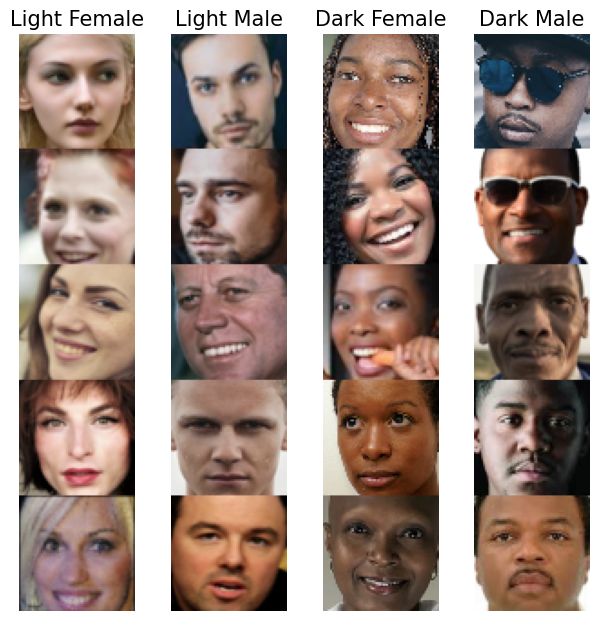

In [89]:
### Load test dataset and plot examples ###

channels_last = False  # Set to False for CHW format (PyTorch default), True for HWC format
test_faces = mdl.lab2.get_test_faces(channels_last=channels_last)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

fig, axs = plt.subplots(1, len(keys), figsize=(7.5, 7.5))
for i, (group, key) in enumerate(zip(test_faces, keys)):
    axs[i].imshow(np.hstack(group).transpose(1, 2, 0))
    axs[i].set_title(key, fontsize=15)
    axs[i].axis("off")

In [91]:
for x in test_faces:            
    print(torch.tensor(x).shape)

torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])
torch.Size([5, 3, 64, 64])


C:\Users\Sahan\AppData\Local\Temp\ipykernel_13124\478933886.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  print(torch.tensor(x).shape)


In [ ]:
test_faces_dict = {}
for (x, key) in zip(test_faces, keys):
    x  = torch.tensor(x, dtype=torch.float32).to(device)
    test_faces_dict[key] = F.interpolate(x, size=(32, 32), mode='bilinear', align_corners=False)
    


In [96]:
transform_new = transforms.Compose([
    transforms.Resize((64, 64)),
    
])

Model expected input size: 64x64
Category: Light Female
  Image 1: False, Probability: 0.4583
  Image 2: False, Probability: 0.4544
  Image 3: False, Probability: 0.4608
  Image 4: False, Probability: 0.4567
  Image 5: False, Probability: 0.4605
Category: Light Male
  Image 1: False, Probability: 0.4626
  Image 2: False, Probability: 0.4639
  Image 3: False, Probability: 0.4617
  Image 4: False, Probability: 0.4587
  Image 5: False, Probability: 0.4569
Category: Dark Female
  Image 1: False, Probability: 0.4641
  Image 2: False, Probability: 0.4562
  Image 3: False, Probability: 0.4628
  Image 4: False, Probability: 0.4594
  Image 5: False, Probability: 0.4604
Category: Dark Male
  Image 1: False, Probability: 0.4629
  Image 2: False, Probability: 0.4570
  Image 3: False, Probability: 0.4583
  Image 4: False, Probability: 0.4681
  Image 5: False, Probability: 0.4581


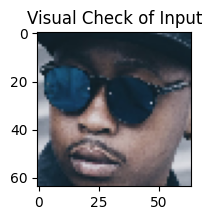

In [113]:
import torch
from torchvision import transforms

# 1. ENSURE MODEL IS IN EVALUATION MODE
# This fixes the Batch Normalization layers
check_model.eval() 

# 2. Define Transform (Must match Training exactly)
# Your training used 64x64, so we must use 64x64 here.
transform_new = transforms.Compose([
    transforms.Resize((64, 64))
])

test_faces_dict = {}
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

# 3. Process the images
for (x, key) in zip(test_faces, keys):
    # x is likely a numpy array or list of shape (3, H, W) based on your print output
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    
    # Ensure shape is (Channel, Height, Width) before resizing
    # If x is (H, W, C), you need x_tensor = x_tensor.permute(2, 0, 1)
    
    # Apply Resize
    x_transformed = transform_new(x_tensor) 
    
    test_faces_dict[key] = x_transformed

standard_classifier_probs_list = []

# 4. Inference Loop
print(f"Model expected input size: 64x64")

for key, imgs in test_faces_dict.items():
    # imgs is currently shape [5, 3, 64, 64]
    
    with torch.no_grad():
        # Pass data to model
        outputs = check_model(imgs) 
        
        # Calculate probabilities
        probs = torch.sigmoid(outputs)
        
        # Prediction Threshold
        preds = probs > 0.5
        
        mean_prob_for_category = probs.mean().item() 
        standard_classifier_probs_list.append(mean_prob_for_category)

    print(f"Category: {key}")
    for i, p in enumerate(preds):
        print(f"  Image {i+1}: {p.item()}, Probability: {probs[i].item():.4f}")

# Optional: Visual Check
# Plot the last image seen to ensure it wasn't distorted
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(imgs[0].cpu().permute(1,2,0)) # Convert (C,H,W) -> (H,W,C) for plot
plt.title("Visual Check of Input")
plt.show()

Text(0.5, 1.0, 'Standard classifier predictions')

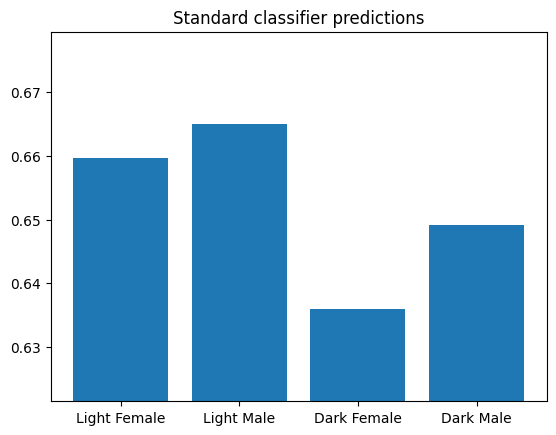

In [ ]:
#  Plot the prediction accuracies per demographic
standard_classifier_probs = np.array(standard_classifier_probs_list)  # shape [4]
xx = range(len(keys))
yy = standard_classifier_probs  # Already aggregated per category
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("Standard classifier predictions")

The equation for the latent loss is provided by:

$$L_{KL}(\mu, \sigma) = \frac{1}{2}\sum_{j=0}^{k-1} (\sigma_j + \mu_j^2 - 1 - \log{\sigma_j})$$

The equation for the reconstruction loss is provided by:

$$L_{x}{(x,\hat{x})} = ||x-\hat{x}||_1$$

Thus for the VAE loss we have:

$$L_{VAE} = c\cdot L_{KL} + L_{x}{(x,\hat{x})}$$

where $c$ is a weighting coefficient used for regularization. Now we're ready to define our VAE loss function:

In [147]:
def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):
    # Sum over Latent Features (dim=1) only. Result is [Batch_Size]
    kl_terms = 0.5 * torch.sum(torch.exp(logsigma) + mu**2 - 1 - logsigma, dim=1) 
    
    # Reconstruction Loss: Sum/Mean over C, H, W (all non-batch dimensions)
    # This also leaves a vector of shape [Batch_Size]
    recon_loss = torch.mean(torch.abs(x - x_recon).view(x.size(0), -1), dim=1)
    
    # Total VAE loss PER SAMPLE (A vector of shape [Batch_Size])
    vae_loss_per_sample = (kl_weight * kl_terms) + recon_loss

    return vae_loss_per_sample


### VAE: Reparameterization Trick

$$z = \mu + e^{\left(\frac{1}{2} \cdot \log{\Sigma}\right)}\circ \epsilon$$

In [120]:
def sampling(z_mean, z_logsigma):
    # Generate random noise with the same shape as z_mean, sampled from a standard normal distribution (mean=0, std=1)
    eps = torch.randn_like(z_mean)

    z = z_mean +  torch.exp(0.5 * z_logsigma) * eps

    return z

### Loss function for DB-VAE

Loss of VAE(only for positve class) + Loss of Classification

In [148]:
import torch.nn.functional as F

def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):
    """Loss function for DB-VAE.
    # Arguments
        x: true input x
        x_pred: reconstructed x
        y: true label (face or not face)
        y_logit: predicted labels
        mu: mean of latent distribution (Q(z|X))
        logsigma: log of standard deviation of latent distribution (Q(z|X))
    # Returns
        total_loss: DB-VAE total loss
        classification_loss = DB-VAE classification loss
    """
    
    vae_loss = vae_loss_function(x, x_pred, mu, logsigma) 

    classification_loss = F.binary_cross_entropy_with_logits(y, y_logit)

    # Use the training data labels to create variable face_indicator:
    #   indicator that reflects which training data are images of faces
    y = y.float()
    face_indicator = (y == 1.0).float()
    
    vae_loss_conditional = vae_loss * face_indicator
    vae_loss_averaged = torch.mean(vae_loss_conditional) 

    # define the DB-VAE total loss! Use torch.mean to average over all
    # samples
    total_loss = classification_loss + vae_loss_averaged 

    return total_loss, classification_loss

### Define the decoder portion of the DB-VAE

In [22]:
class FaceDecoder(nn.Module):
    def __init__ (self, latent_dim=100, input_dim=128 * 4 * 4):
        super(FaceDecoder, self).__init__()
            
        self.latent_dim = latent_dim
        self.input_dim = input_dim
            
        # (B, 100) -> (B, input_dim): later will reshpae to (B, 128, 4, 4)
        self.linear = nn.Sequential(
            nn.Linear(self.latent_dim, input_dim),
            nn.ReLU() 
        )
            
        self.deconv = nn.Sequential(
            # 1. (B, 128, 4, 4) -> (B, 64, 8, 8)
            nn.ConvTranspose2d(
                in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),
            # 2. (B, 64, 8, 8) -> (B, 32, 16, 16)
            nn.ConvTranspose2d(
                in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),
            # 3. (B, 32, 16, 16) -> (B, 3, 32, 32)
            nn.ConvTranspose2d(
                in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1
            ), 
            nn.ReLU(),
            # 4. (B, 3, 32, 32) -> (B, 3 ,64, 64)
            nn.ConvTranspose2d(
                in_channels=3, out_channels=3,kernel_size=4, stride=2, padding=1
            ), 
        )
    
    def forward(self, z):
        x = self.linear(z)
        x = x.view(-1, 128, 4, 4)
        x = self.deconv(x)
            
        return x

### Build the DB-VAE model

In [23]:
class DB_VAE(nn.Module):
    def __init__(self, latent_dim=100):
        super(DB_VAE, self).__init__()
        
        self.latent_dim = latent_dim
        
        self.encoder = Face_CNN(2*latent_dim + 1)
        self.decoder = FaceDecoder(latent_dim)
        
    def encode(self, x):
        encoder_output = self.encode(x)
        
        y_logit = encoder_output[:, 0].unsqueeze(-1)
        
        # latent variable distribution parameters
        z_mean = encoder_output[:, 1 : self.latent_dim + 1]
        z_logsigma = encoder_output[:, self.latent_dim + 1 :]
        return y_logit, z_mean, z_logsigma
        
    def reparameterize(self, z_mean, z_logsigma):
        z = sampling(z_mean, z_logsigma)
        return z
        
    def decode(self, z):
        recon_x = self.decoder(z)
        return recon_x
    
    def forward(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        z = self.reparameterize(z_mean, z_logsigma)
        recon_x = self.decode(z)
        
        return y_logit, z_mean, z_logsigma, recon_x
    
    def predict(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        
        return y_logit
    

db_vae = DB_VAE()
    

In [24]:
db_vae

DB_VAE(
  (encoder): Face_CNN(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=2048, out_fe

In [73]:
def get_latent_mu_from_loader(loader, dbvae, device):
    """
    Runs the entire dataset through the DB-VAE to get the latent means (mu).
    Using a DataLoader is much more memory efficient than loading all arrays.
    """
    dbvae.eval()
    all_z_mean = []

    with torch.no_grad(): # Use no_grad (same as inference_mode)
        for images, labels in loader:
            images = images.to(device)
            # Forward pass: we only care about z_mean here
            # dbvae return: y_logit, z_mean, z_logsigma, x_recon
            _, z_mean, _, _ = dbvae(images)
            all_z_mean.append(z_mean.cpu())

    # Concatenate all batches into one large tensor [N_train, latent_dim]
    return torch.cat(all_z_mean, dim=0).numpy()

In [76]:
# def get_training_sample_probabilities(loader, dbvae, device, bins=10, smoothing_fac=0.001):
#     print("Recomputing the sampling probabilities...")

#     # 1. Get mu for the whole dataset using the loader
#     mu = get_latent_mu_from_loader(loader, dbvae, device) 
    
#     # 2. Initialize probabilities
#     training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)

#     # 3. Loop over latent variables (Same logic as before)
#     # Note: We assume dbvae.latent_dim matches mu.shape[1]
#     latent_dim = mu.shape[1]
    
#     for i in range(latent_dim):
#         latent_distribution = mu[:, i]
#         hist_density, bin_edges = np.histogram(latent_distribution, density=True, bins=bins)

#         # Handle edges
#         bin_edges[0] = -float("inf")
#         bin_edges[-1] = float("inf")

#         # Find bins
#         bin_idx = np.digitize(latent_distribution, bin_edges)

#         # Smooth and Invert
#         hist_smoothed_density = hist_density + smoothing_fac
#         hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)
#         p = 1.0 / (hist_smoothed_density[bin_idx - 1])
        
#         # Normalize and Update
#         p /= np.sum(p)
#         training_sample_p = np.maximum(training_sample_p, p)

#     # Final Normalization
#     training_sample_p /= np.sum(training_sample_p)

#     return training_sample_p

In [ ]:
def get_training_sample_probabilities(loader, dbvae, device, bins=10, smoothing_fac=0.001):
    print("Recomputing the sampling probabilities...")
    
    # 1. Get mu and LABELS for the whole dataset
    dbvae.eval()
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, z_mean, _, _ = dbvae(images)
            all_mu.append(z_mean.cpu())
            all_labels.append(labels.cpu())
            
    mu = torch.cat(all_mu, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy() # Shape (N,)
    
    # 2. Initialize probabilities
    # We will manipulate this array
    training_sample_p = np.zeros(mu.shape[0], dtype=np.float64)
    
    # 3. Identify Indices
    face_indices = np.where(labels == 1)[0]
    non_face_indices = np.where(labels == 0)[0]
    
    # ==============================================================
    # PART A: CALCULATE DEBIASING PROBS FOR FACES ONLY
    # ==============================================================
    # We only look at the distribution of FACES to calculate rarity
    faces_mu = mu[face_indices]
    
    # Initialize face probs
    faces_p = np.zeros(len(face_indices), dtype=np.float64)
    
    latent_dim = mu.shape[1]
    for i in range(latent_dim):
        latent_distribution = faces_mu[:, i]
        hist_density, bin_edges = np.histogram(latent_distribution, density=True, bins=bins)
        
        # Edges
        bin_edges[0] = -float("inf")
        bin_edges[-1] = float("inf")
        
        # Digitize
        bin_idx = np.digitize(latent_distribution, bin_edges)
        
        # Smooth & Invert
        hist_smoothed_density = hist_density + smoothing_fac
        hist_smoothed_density /= np.sum(hist_smoothed_density)
        
        p = 1.0 / (hist_smoothed_density[bin_idx - 1])
        p /= np.sum(p)
        
        # Update
        faces_p = np.maximum(faces_p, p)
        
    # ==============================================================
    # PART B: BALANCE THE DATASET
    # ==============================================================
    # Now we have the "relative" importance of each face.
    # We need to ensure that Sum(Face Probs) ~= Sum(Non-Face Probs)
    # so the sampler picks them roughly 50/50.
    
    # 1. Normalize Face Probs to sum to 0.5
    faces_p /= np.sum(faces_p)
    faces_p *= 0.5
    
    # 2. Assign Non-Face Probs to sum to 0.5 (Uniformly)
    # Each non-face gets the same weight
    num_non_faces = len(non_face_indices)
    if num_non_faces > 0:
        non_face_p_val = 0.5 / num_non_faces
    else:
        non_face_p_val = 0.0
        
    # 3. Fill the main array
    training_sample_p[face_indices] = faces_p
    training_sample_p[non_face_indices] = non_face_p_val
    
    return training_sample_p

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=2,  # DB-VAE needs slightly more epochs to train
)

def debiasing_train_step(x, y):
    optimizer.zero_grad()

    y_logit, z_mean, z_logsigma, x_recon = dbvae(x)

    '''TODO: call the DB_VAE loss function to compute the loss'''
    loss, class_loss = debiasing_loss_function('''TODO arguments''') # TODO

    loss.backward()
    optimizer.step()

    return loss

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dbvae = DB_VAE(latent_dim=100).to(device) # Instantiate your model

# 2. Define a standard loader for the "Analysis Phase" (Order matters, no shuffle)
# We use this ONLY to extract 'mu' in the exact order of the dataset
analysis_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

# Training Loop
for i in range(params["num_epochs"]):
    print(f"Starting epoch {i + 1}/{params['num_epochs']}")
    
    # ============================================
    # A. ANALYSIS PHASE (Calculate Probabilities)
    # ============================================
    # Pass the analysis_loader to scan the dataset
    p_faces = get_training_sample_probabilities(analysis_loader, dbvae, device)
    
    # ============================================
    # B. CREATE WEIGHTED LOADER
    # ============================================
    # Use the calculated probabilities (p_faces) as weights
    sampler = WeightedRandomSampler(
        weights=p_faces, 
        num_samples=len(train_dataset), 
        replacement=True
    )
    
    # This loader will now return rare faces more often
    weighted_train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        sampler=sampler
    )
    
    # ============================================
    # C. TRAINING PHASE
    # ============================================
    dbvae.train() # Make sure model is in train mode
    
    for x, y in tqdm(weighted_train_loader):
        x = x.to(device)
        y = y.to(device) # Ensure labels are float for BCE loss if needed
        
        loss = debiasing_train_step(x, y)
        
        # Log your loss here...